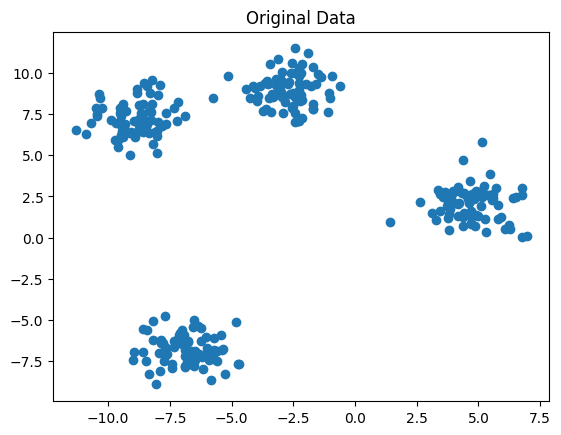

In [1]:
#Step 1: Create Dataset

from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

plt.scatter(X[:,0], X[:,1])
plt.title("Original Data")
plt.show()

In [2]:
X.shape

(300, 2)

In [5]:
print(X[:10])   # show first 10 rows

[[ -9.29768866   6.47367855]
 [ -9.69874112   6.93896737]
 [ -1.68665271   7.79344248]
 [ -7.09730839  -5.78133274]
 [-10.87645229   6.3154366 ]
 [ -6.02196757  -7.04004812]
 [  4.81305976   2.35848706]
 [ -6.46669574  -7.44383415]
 [ -2.98837186   8.82862715]
 [  3.44857534   2.62972329]]


In [6]:
import pandas as pd
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
print(df.head())

    Feature1  Feature2
0  -9.297689  6.473679
1  -9.698741  6.938967
2  -1.686653  7.793442
3  -7.097308 -5.781333
4 -10.876452  6.315437


In [7]:
print(df.describe())

         Feature1    Feature2
count  300.000000  300.000000
mean    -3.403837    2.845329
std      5.289154    6.225742
min    -11.309972   -8.919342
25%     -7.952236   -1.181119
50%     -4.708134    5.066995
75%     -0.117606    8.079443
max      6.954537   11.477528


In [8]:
from sklearn.datasets import make_blobs
import pandas as pd

# Create dataset
X, _ = make_blobs(
    n_samples=1000,
    centers=5,          # assume 5 customer groups
    n_features=3,       # 3 features
    cluster_std=1.5,
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(X, columns=['Age', 'Income', 'SpendingScore'])

print(df.head())

        Age     Income  SpendingScore
0  3.183060  -6.304206     -10.434692
1 -1.693973  10.566668       1.327719
2  6.235300  -4.342174      -5.619253
3  2.523823  -7.668335      -7.076667
4  5.510649  -6.647273      11.089234


In [9]:
#Step 2: Data Preprocessing (VERY IMPORTANT)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

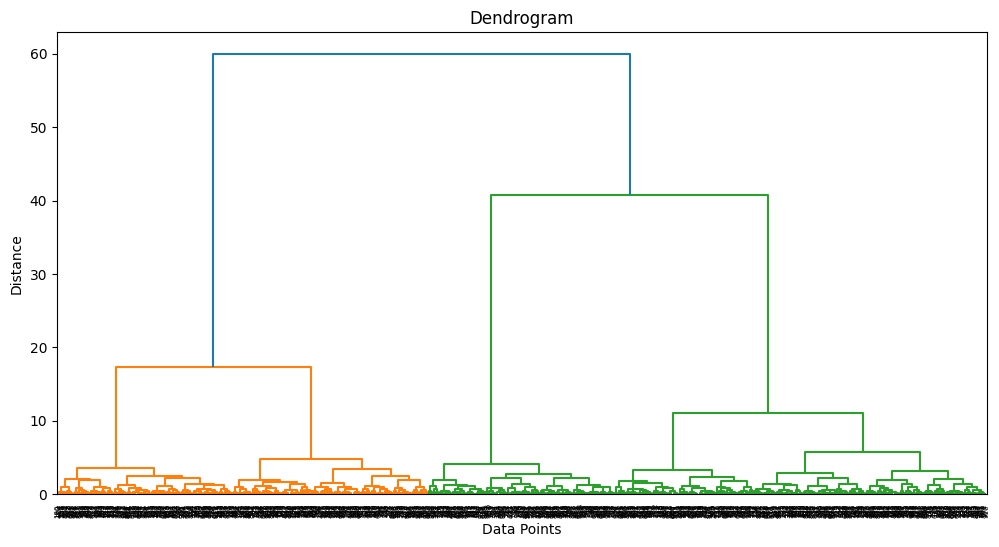

In [10]:
#Step 3: Build Dendrogram (Find Optimal Clusters)

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [11]:
#Step 4: Apply Hierarchical Clustering

from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

labels = model.fit_predict(X_scaled)

In [12]:
print(df.head())

        Age     Income  SpendingScore
0  3.183060  -6.304206     -10.434692
1 -1.693973  10.566668       1.327719
2  6.235300  -4.342174      -5.619253
3  2.523823  -7.668335      -7.076667
4  5.510649  -6.647273      11.089234


In [13]:
labels

array([0, 1, 4, 0, 2, 2, 1, 3, 3, 0, 4, 0, 4, 2, 2, 4, 1, 0, 2, 3, 3, 0,
       0, 4, 2, 1, 2, 0, 4, 1, 2, 3, 1, 3, 2, 2, 3, 0, 0, 2, 4, 2, 3, 2,
       3, 1, 1, 2, 2, 3, 0, 2, 2, 0, 0, 4, 0, 4, 4, 0, 1, 0, 3, 3, 3, 2,
       1, 0, 2, 2, 2, 0, 0, 1, 1, 2, 0, 1, 0, 1, 2, 1, 0, 4, 2, 1, 0, 3,
       1, 1, 2, 0, 2, 2, 1, 1, 3, 0, 2, 1, 2, 3, 1, 2, 3, 0, 1, 0, 2, 2,
       0, 2, 3, 1, 3, 0, 1, 3, 3, 1, 4, 4, 3, 0, 0, 1, 2, 0, 3, 3, 1, 4,
       1, 3, 1, 2, 2, 1, 3, 1, 4, 2, 4, 0, 3, 2, 0, 2, 4, 3, 4, 2, 0, 1,
       1, 1, 2, 4, 3, 1, 1, 0, 0, 3, 3, 0, 0, 0, 2, 1, 3, 0, 3, 4, 0, 3,
       1, 3, 2, 3, 3, 1, 3, 2, 4, 3, 1, 0, 0, 1, 3, 1, 2, 3, 2, 1, 3, 1,
       1, 1, 4, 1, 4, 4, 3, 3, 2, 3, 2, 3, 1, 0, 1, 2, 0, 0, 1, 0, 3, 0,
       4, 2, 2, 0, 0, 0, 3, 4, 2, 1, 4, 4, 4, 2, 3, 4, 0, 0, 3, 4, 2, 2,
       0, 1, 2, 0, 3, 2, 1, 0, 3, 0, 4, 0, 2, 3, 0, 2, 1, 4, 2, 4, 4, 2,
       0, 2, 2, 3, 4, 1, 2, 3, 0, 4, 3, 0, 0, 0, 0, 2, 1, 2, 4, 2, 2, 0,
       1, 1, 0, 2, 1, 2, 4, 1, 1, 4, 4, 1, 0, 3, 3,

In [14]:
#Step 5: Attach Cluster Labels to Dataset

df['Cluster'] = labels

print(df.head())

        Age     Income  SpendingScore  Cluster
0  3.183060  -6.304206     -10.434692        0
1 -1.693973  10.566668       1.327719        1
2  6.235300  -4.342174      -5.619253        4
3  2.523823  -7.668335      -7.076667        0
4  5.510649  -6.647273      11.089234        2


In [15]:
df['Cluster'].value_counts()

Cluster
0    252
1    210
2    200
3    190
4    148
Name: count, dtype: int64

In [16]:
#Step 6: Evaluate Clustering (Metrics)

#1. Silhouette Score (Most Important)

from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.5459201500229951


Interpretation:

> 0.7 → Excellent
0.5 – 0.7 → Good
< 0.3 → Poor

In [17]:
#2. Davies-Bouldin Index

#👉 Lower is better (closer to 0)

from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(X_scaled, labels)
print("Davies-Bouldin Score:", db_score)

Davies-Bouldin Score: 0.6589301268318128


In [18]:
#If you want to see only cluster 0

cluster_0_df = df[df['Cluster'] == 0]